### EDA on the data

- Given that test set has no labels for comparison, the train data will be considered the full data

In [ ]:
from PIL import Image, ImageOps
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from collections import Counter
import shutil

import pandas as pd
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# create dependency group for eda  
# uv sync --group eda
# uv add --group eda pandas

### Get image properties distribution

In [12]:
data_dir = Path("../data/dataset/images/train").resolve()

# like a dictionary but counts occurrence 
sizes = Counter()
modes = Counter()
 
for fn in data_dir.iterdir():
    try:
        with Image.open(fn) as img:
            sizes[img.size] += 1   
            modes[img.mode] += 1   
    except Exception as e:
        print(f"Skipped {fn.name}: {e}")


total_images = sum(1 for fn in data_dir.iterdir() if fn.is_file())
print(f"\nTotal images: {total_images}")

# start with most common first when using .most_common()
print("Image mode count: ")
for mode, count in modes.most_common():
    print(f"  {mode}: {count}")

print("Image size count: ")
for size, count in sizes.most_common():
    print(f"  {size}: {count}")


Total images: 5529
Image mode count: 
  RGB: 5529
Image size count: 
  (4032, 3024): 1124
  (960, 1280): 800
  (1536, 2048): 673
  (2448, 3264): 650
  (810, 1080): 464
  (416, 416): 374
  (3264, 2448): 278
  (4128, 3096): 273
  (576, 1280): 150
  (1280, 960): 136
  (1080, 810): 133
  (4000, 1800): 132
  (3024, 3024): 121
  (1280, 576): 39
  (2048, 1536): 35
  (3024, 4032): 33
  (958, 1280): 29
  (720, 1280): 24
  (2448, 2448): 16
  (3264, 1472): 10
  (1088, 1920): 10
  (577, 1280): 7
  (808, 1080): 2
  (1280, 577): 2
  (1836, 2606): 1
  (1280, 900): 1
  (778, 1080): 1
  (613, 1080): 1
  (608, 1080): 1
  (617, 709): 1
  (689, 1080): 1
  (807, 1080): 1
  (1495, 2048): 1
  (1211, 1280): 1
  (768, 1024): 1
  (738, 1080): 1
  (1280, 720): 1
  (1615, 1546): 1


- All images are RGB and all can be read 
- Images come in different sizes, so there is need to pre-process them to the same size and scale the corresponding bounding boxes as well 

### CSV data distribution

In [2]:
data_fp = Path("../data/Train.csv").resolve()
df = pd.read_csv(data_fp)

# check for any empty rows 
print(f" Number of rows that has NaN:\n{df.isna().sum()}")
# no rows with empty column values 

# check for any inconsistent labelling between class and class_id 
# count the number of class id per class
df.groupby("class")["class_id"].value_counts()


 Number of rows that has NaN:
Image_ID      0
class         0
confidence    0
ymin          0
xmin          0
ymax          0
xmax          0
class_id      0
ImagePath     0
dtype: int64


class        class_id
anthracnose  0           2271
cssvd        1           3223
             0             18
healthy      2           4279
             1              1
Name: count, dtype: int64

- No rows with empty columns
- there is inconsistent labelling, since there is no way to know which is true, remove rows with inconsistent labels
- the number of rows removed is not much ~ 19/10000 images
- cleaned_df is the dataframe with rows removed 

In [5]:
# remove rows with inconsistent labels 
mask = (
    ((df["class"] == "healthy") & (df["class_id"] == 1)) |
    ((df["class"] == "cssvd")   & (df["class_id"] == 0))
)

cleaned_df = df[~mask]

# get class distribution
counts = cleaned_df.groupby("class")["class_id"].value_counts()
(counts / counts.sum() * 100).round(2)


class        class_id
anthracnose  0           23.24
cssvd        1           32.98
healthy      2           43.78
Name: count, dtype: float64

- Dataset is imbalanced
- There is 3 classes, where anthracnose and cssvd are two disease affecting cacao plants

### Check if bounding boxes exceed image dimensions so to clean data

In [ ]:
img_dir = Path("../data/").resolve()

def process_row(args):
    idx, row = args
    with Image.open(img_dir / row["ImagePath"]) as img:
        img = ImageOps.exif_transpose(img) # applies EXIF rotation to get the correct orientation of image
        w, h = img.width, img.height

    is_invalid = (row["xmin"] < 0 or row["ymin"] < 0 or
                  row["xmax"] > w or row["ymax"] > h)
    return idx, w, h, is_invalid

# allow reuse of thread, load balance task, good for reading images  
with ThreadPoolExecutor(max_workers=4) as executor:
    results = list(executor.map(process_row, cleaned_df.iterrows()))

invalid_rows = []
for idx, w, h, is_invalid in results:
    cleaned_df.at[idx, "img_width"] = w
    cleaned_df.at[idx, "img_height"] = h
    if is_invalid:
        invalid_rows.append(idx)

invalid_df = cleaned_df.loc[invalid_rows]
print(f"Invalid bounding boxes: {len(invalid_df)}")
print(invalid_df)


Invalid bounding boxes: 37
           Image_ID        class  confidence   ymin    xmin    ymax    xmax  \
303   ID_CmbGmt.jpg      healthy         1.0   24.0     2.0   417.0   416.0   
431   ID_RUEBT5.jpg      healthy         1.0   27.0   303.0   139.0   417.0   
642   ID_SPyd52.jpg      healthy         1.0    1.0   165.0   172.0   417.0   
672   ID_JWGCGl.jpg      healthy         1.0   42.0   261.0   103.0   417.0   
775   ID_ofOgxi.jpg      healthy         1.0  137.0   244.0   360.0   417.0   
926   ID_c2XesD.jpg      healthy         1.0  269.0    82.0   416.0   417.0   
1204  ID_XbC4LO.jpg      healthy         1.0    5.0   112.0   416.0   417.0   
1210  ID_mKxmKN.jpg      healthy         1.0    3.0    27.0   416.0   417.0   
1399  ID_sAk119.jpg      healthy         1.0  221.0    25.0   417.0   154.0   
1401  ID_sAk119.jpg      healthy         1.0   63.0   175.0   163.0   417.0   
1522  ID_LTHG5W.jpg      healthy         1.0    1.0     1.0   417.0   416.0   
1788  ID_FIJmp6.jpg      

- 37 images with bounding box exceed image dimensions
- all bounding box just exceed the max width/height dimension by 1 pixel
- update the data to clip the bounding box to the max dimension instead of dropping those rows

In [ ]:
# function to clip the bounding
def clip_bbox(row):
    # update columns for each row
    row["xmin"] = max(0, row["xmin"])
    row["ymin"] = max(0, row["ymin"])
    row["xmax"] = min(row["img_width"], row["xmax"])
    row["ymax"] = min(row["img_height"], row["ymax"])
    return row

# apply to each row
updated_df = cleaned_df.apply(clip_bbox, axis=1)

In [18]:
with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(process_row, updated_df.iterrows()))

invalid_rows = []
for idx, w, h, is_invalid in results:
    if is_invalid:
        invalid_rows.append(idx)

invalid_df = updated_df.loc[invalid_rows]
print(f"Invalid bounding boxes: {len(invalid_df)}")
print(invalid_df)

Invalid bounding boxes: 0
Empty DataFrame
Columns: [Image_ID, class, confidence, ymin, xmin, ymax, xmax, class_id, ImagePath, img_width, img_height]
Index: []


- Clip the bounding boxes and verified that there is no invalid bounding boxes anymore
- updated_df is the dataframe with the corrected bounding boxes

### Get distribution of detection per image and number of class per image

In [ ]:
# get the number of rows per image (each row is one detection)
detections_per_image_df = updated_df.groupby("Image_ID").size().rename("detection_count").reset_index()

print(f"number of images is : {len(detections_per_image_df)}")
# get the distribution
print("Distribution of detection per image")
detection_dist = detections_per_image_df['detection_count'].value_counts().sort_index()
print(detection_dist)

# get number of classes detected per image
num_class_per_image_df = updated_df.groupby("Image_ID")["class"].nunique().rename("number_class").reset_index()

# get the distribution
print("Distribution of number of classes per image")
num_class_dist = num_class_per_image_df['number_class'].value_counts().sort_index()
print(num_class_dist)

number of images is : 5516
Distribution of detection per image
detection_count
1     3199
2     1256
3      606
4      247
5       98
6       61
7       27
8        6
9        6
10       4
11       4
12       1
13       1
Name: count, dtype: int64
Distribution of number of classes per image
number_class
1    5510
2       6
Name: count, dtype: int64


- After cleaning the data, the number of images in dataset is 5516
- For most images, there is 1/2 detection per image, but there is a handful of images where there is above 10 detections per image
- Most images contains leaves belonging to the same class, only 6 images has leaves belonging to 2 classes 

### Save the updated dataframe and update the image folder as well

In [37]:
updated_df.reset_index(drop=True, inplace=True)

updated_df.to_csv(Path("../data").resolve()/ "clean_data.csv", index=False )

In [ ]:
all_image_id = updated_df["Image_ID"].unique().tolist()

src_folder = Path("../data/dataset/images/train").resolve()
dst_folder = Path("../data/dataset/images/clean_data").resolve()
dst_folder.mkdir(exist_ok=True)

def copy_file(image_id):
    src = src_folder / image_id
    if src.exists():
        shutil.copy(src, dst_folder / image_id)
    else:
        print(f"Not found: {image_id}")

with ThreadPoolExecutor(max_workers=8) as executor:
    executor.map(copy_file, all_image_id)


### Plot the bounding box over the image 

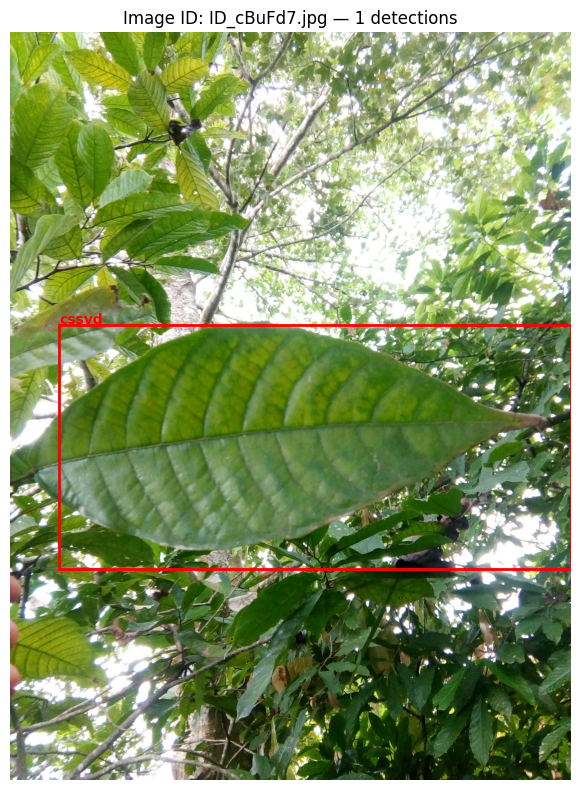

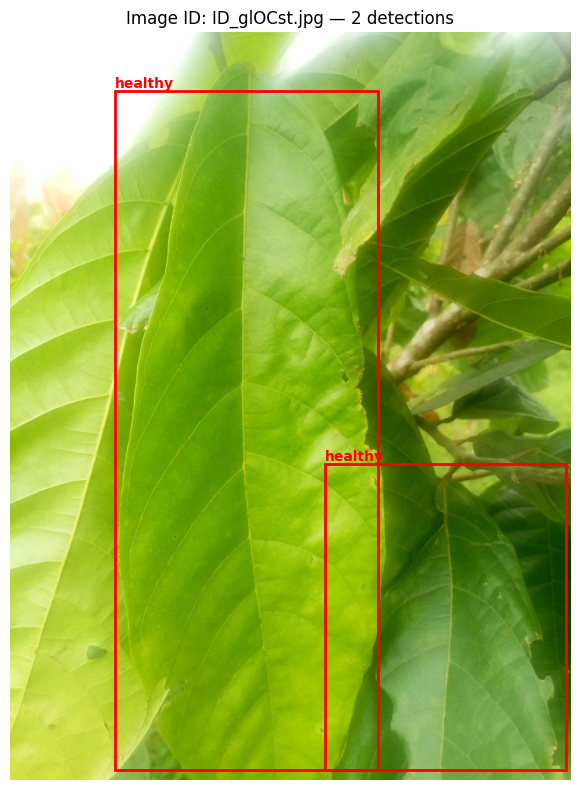

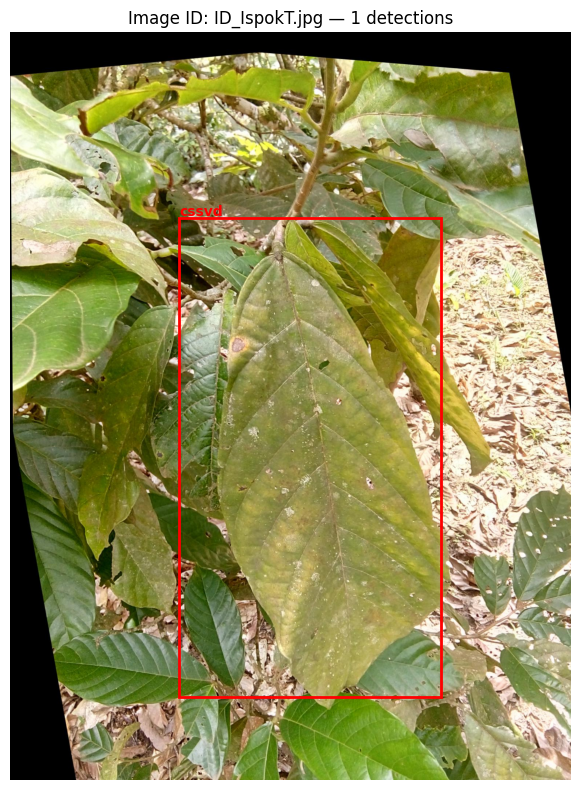

In [ ]:
def plot_image_with_bboxes(df, image_id, img_dir):
    rows = df[df["Image_ID"] == image_id]

    if rows.empty:
        print(f"No rows found for Image_ID: {image_id}")
        return

    img_path = img_dir / rows.iloc[0]["Image_ID"]
    img = Image.open(img_path)

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img)
    # all bounding boxes
    for _, row in rows.iterrows():
        x, y = row["xmin"], row["ymin"]
        w, h = row["xmax"] - row["xmin"], row["ymax"] - row["ymin"]

        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        # add label 
        ax.text(x, y - 5, row["class"], color="red", fontsize=10, fontweight="bold")

    ax.set_title(f"Image ID: {image_id} — {len(rows)} detections")
    ax.axis("off")  # remove tick marks and axis lines
    plt.tight_layout()
    plt.show()


data_dir = Path("../data/dataset/images/clean_data").resolve()

# set seed 
random.seed(11)
sampled_id = random.sample(all_image_id, 3)

for k in sampled_id:
    plot_image_with_bboxes(updated_df, k, data_dir)

- Even though there are multiple leaves in an image, the detection is done mainly on the largest leaf and not on all the leaves in the image

- Model might be trained to detect the main leaves and ignore smaller leaves which will be missed
- This is a limitation of the dataset, since it is difficult to add in more labels without knowing how leaves are classified